# Setting up

In [13]:
# IMPORTS
import pandas as pd
import time
import matplotlib.pyplot as plt

In [14]:
# PARAMETERS

train_path = "data/basic_dataset.csv"
train_path = "data/training_set_VU_DM.csv"
# for testing: train_path = "data/small_dataset.csv"
save_output = True


In [15]:
# LOAD DATA

start_time = time.time()
chunk = pd.read_csv(train_path, chunksize=1000000)
print(f"load chunk: {time.time() - start_time:.2f}s")

start_time = time.time()
df = pd.concat(chunk)
print(f"concat df: {time.time() - start_time:.2f}s")

load chunk: 0.00s
concat df: 11.48s


In [19]:
df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


### Describing the entire dataset

# Comp Columns analysis

In [ ]:
# Description of feature "comp"


# comp1_rate Integer:
# +1 if Expedia has a lower price than competitor 1 for the hotel; 0 if the same; -1 if Expedia’s price is higher than competitor 1; null signifies there is no competitive data

# comp1_inv Integer
# +1 if competitor 1 does not have availability in the hotel; 0 if both Expedia and competitor 1 have availability; null signifies there is no competitive data

# comp1_rate_percent_diff Float
# The absolute percentage difference (if one exists) between Expedia and competitor 1’s price (Expedia’s price the denominator); null signifies there is no competitive data

# The same for the other "compN" features, where N is the competitor number

In [17]:
# number of competitors
n_competitors = 8
# suffixes for the columns
suffixes = ["rate", "inv", "rate_percent_diff"]

complete_df_columns = df.columns
comp_columns = []
for c in complete_df_columns:
    if "comp" in c:
        comp_columns.append(c)

print(comp_columns)

# create a dataframe with number of missing values, count and percentage of missing values for each comp column

comp_missing = pd.DataFrame(index = ["missing_values", "count", "percentage_missing"], columns = comp_columns)

for c in comp_columns:
    comp_missing.loc["missing_values", c] = df[c].isna().sum()
    comp_missing.loc["count", c] = df[c].count()
    comp_missing.loc["percentage_missing", c] = df[c].isna().sum() / df.shape[0] * 100

comp_missing


['comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv', 'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv', 'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv', 'comp8_rate_percent_diff']


,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,...,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff
missing_values,4838417,4828788,4863908,2933675,2828078,4402109,3424059,3307357,4485550,4650969,...,4117248,4718190,4697371,4862173,4642999,4601925,4819832,3041693,2970844,4343617
count,119930,129559,94439,2024672,2130269,556238,1534288,1650990,472797,307378,...,841099,240157,260976,96174,315348,356422,138515,1916654,1987503,614730
percentage_missing,97.58125,97.387053,98.095353,59.166392,57.03671,88.781786,69.056462,66.702814,90.464625,93.800797,...,83.036706,95.156511,94.736633,98.060362,93.640058,92.811677,97.206428,61.3449,59.916016,87.602118


In [5]:
# Count rows of the origina df that miss all comp columns
missing_all = df[df[comp_columns].isna().all(axis=1)]
# print number of rows that miss all comp columns and the percentage of the total

print(f"Number of rows that miss all comp columns: {missing_all.shape[0]}")
print(f"Percentage of the total: {missing_all.shape[0] / df.shape[0] * 100:.2f}%")

booked_df = df[df.booking_bool == 1]
# do the same but for booked rows
missing_all_booked = booked_df[booked_df[comp_columns].isna().all(axis=1)]
print(f"Number of rows that miss all comp columns: {missing_all_booked.shape[0]}")
print(f"Percentage of the total: {missing_all_booked.shape[0] / booked_df.shape[0] * 100:.2f}%")

Number of rows that miss all comp columns: 1605973
Percentage of the total: 32.39%
Number of rows that miss all comp columns: 40496
Percentage of the total: 29.26%


### Calculated missing values for grouped features

In [6]:
inv_columns = [c for c in comp_columns if c.endswith("_inv")]
rate_columns = [c for c in comp_columns if c.endswith("_rate")]

In [7]:
assert df[inv_columns].isin([0, 1, None]).all(axis=1).all(axis=0)

AssertionError: 

In [8]:
assert df[inv_columns].isin([-1, 0, 1, None]).all(axis=1).all(axis=0)


In [9]:
assert df[rate_columns].isin([-1, 0, 1, None]).all(axis=1).all(axis=0)

In [10]:
# count the number of -1 values in inv columns
num_of_neg = df[inv_columns].isin([-1]).sum(axis=1).sum(axis=0)

print(f"the number of negative values is {num_of_neg}")

num_of_regular_values = df[inv_columns].isin([0, 1]).sum(axis=1).sum(axis=0)
print(f"the number of regular values is {num_of_regular_values}")

the number of negative values is 116311
the number of regular values is 9103091


In [14]:
df[inv_columns] = df[inv_columns].replace(-1, None)

the number of nan values is 4958347


In [12]:
# do the same but grup by suffixes
comp_missing_grouped = pd.DataFrame(index = ["missing_values", "count", "percentage_missing"], columns = suffixes)

for s in suffixes:
    columns = [c for c in comp_columns if c.endswith(s)]
    comp_missing_grouped.loc["missing_values", s] = df[columns].isna().all(axis=1).sum()
    comp_missing_grouped.loc["count", s] = df.shape[0] - comp_missing_grouped.loc["missing_values", s]
    comp_missing_grouped.loc["percentage_missing", s] = df[columns].isna().all(axis=1).sum() / df.shape[0] * 100

comp_missing_grouped

,rate,inv,rate_percent_diff
missing_values,1716808,1653381,3377857
count,3241539,3304966,1580490
percentage_missing,34.624604,33.345407,68.124659


In [18]:
# do the same but group by competitors
comp_missing_grouped = pd.DataFrame(index = ["missing_values", "count", "percentage_missing"], columns = [f"comp{i}" for i in range(1, n_competitors + 1)])

for i in range(1, n_competitors + 1):
    columns = [c for c in comp_columns if f"comp{i}" in c]
    comp_missing_grouped.loc["missing_values", f"comp{i}"] = df[columns].isna().all(axis=1).sum()
    comp_missing_grouped.loc["count", f"comp{i}"] = df.shape[0] - comp_missing_grouped.loc["missing_values", f"comp{i}"]
    comp_missing_grouped.loc["percentage_missing", f"comp{i}"] = df[columns].isna().all(axis=1).sum() / df.shape[0] * 100

comp_missing_grouped

,comp1,comp2,comp3,comp4,comp5,comp6,comp7,comp8
missing_values,4828788,2828078,3307357,4614684,2598327,4697371,4601925,2970844
count,129559,2130269,1650990,343663,2360020,260976,356422,1987503
percentage_missing,97.387053,57.03671,66.702814,93.069001,52.403089,94.736633,92.811677,59.916016


In [23]:
# check for if com if a missing value in rate implies a missing value in inv

comp_missing_grouped = pd.DataFrame(index=["OR_missing_values", "AND_missing_values", "count", "percentage_missing"], columns=[f"comp{i}" for i in range(1, n_competitors + 1)])

for i in range(1, n_competitors + 1):
    columns_rate = [c for c in comp_columns if f"comp{i}" in c and c.endswith("rate")]
    assert len(columns_rate) == 1
    columns_inv = [c for c in comp_columns if f"comp{i}" in c and c.endswith("inv")]
    assert len(columns_inv) == 1

    rate_col = columns_rate[0]
    inv_col = columns_inv[0]

    # Calculate OR_missing_values
    or_missing_values = df[rate_col].isna() | df[inv_col].isna()
    comp_missing_grouped.loc["OR_missing_values", f"comp{i}"] = or_missing_values.sum()

    # Calculate AND_missing_values
    and_missing_values = df[rate_col].isna() & df[inv_col].isna()
    comp_missing_grouped.loc["AND_missing_values", f"comp{i}"] = and_missing_values.sum()

    # Calculate count (neither rate nor inv is missing)
    comp_missing_grouped.loc["count", f"comp{i}"] = comp_missing_grouped.loc["OR_missing_values", f"comp{i}"]

    # Calculate percentage_missing (percentage of rows where neither rate nor inv is missing)
    comp_missing_grouped.loc["percentage_missing", f"comp{i}"] = comp_missing_grouped.loc["count", f"comp{i}"] / df.shape[0] * 100

comp_missing_grouped


,comp1,comp2,comp3,comp4,comp5,comp6,comp7,comp8
OR_missing_values,4838417,2933675,3424059,4650969,2735974,4718190,4642999,3041693
AND_missing_values,4828788,2828078,3307357,4614684,2598327,4697371,4601925,2970844
count,4838417,2933675,3424059,4650969,2735974,4718190,4642999,3041693
percentage_missing,97.58125,59.166392,69.056462,93.800797,55.179155,95.156511,93.640058,61.3449


In [16]:
# create aggregated column features for "rate" and "inv", aggregating the information of the 8 competitors 
# set the rate to 0 if the rates are missing or are 0 Case 1
# set the rate to 1 if the rates are missing or are 1 Case 2
# set the rate to -1 if the rates are missing or are -1 Case 3
# set the rate to the mean if we have different values for different competitors Case 4
# if all rates are missing, set the rate to 0 Case 5

# set the inv to 0 if the invs are missing or are 0 Case 1
# set the inv to 1 if the invs are missing or are 1 Case 2
# set the inv to to the mean if we have different values for different competitors Case 3
# if all invs are missing, set the inv to 0.5 Case 4

# create the aggregated columns
df["comp_rate_agg"] = 0
df["comp_inv_agg"] = 0






### Creating the composite features

In [10]:
from tqdm import tqdm

['comp1_rate', 'comp2_rate', 'comp3_rate', 'comp4_rate', 'comp5_rate', 'comp6_rate', 'comp7_rate', 'comp8_rate']
['comp1_inv', 'comp2_inv', 'comp3_inv', 'comp4_inv', 'comp5_inv', 'comp6_inv', 'comp7_inv', 'comp8_inv']


In [23]:
# mean of the rates
df["comp_rate_agg"] = df[rate_columns].sum(axis=1)

# where all values are missing set to 0
df.loc[df[rate_columns].isna().all(axis=1), "comp_rate_agg"] = 0

# mean of the invs
df["comp_inv_agg"] = (df[inv_columns]-0.5).sum(axis=1)

print(f"the number of nan values is {df["comp_inv_agg"].isna().sum()}")

# where all values are missing set to 0
df.loc[df[inv_columns].isna().all(axis=1), "comp_inv_agg"] = 0


the number of nan values is 0


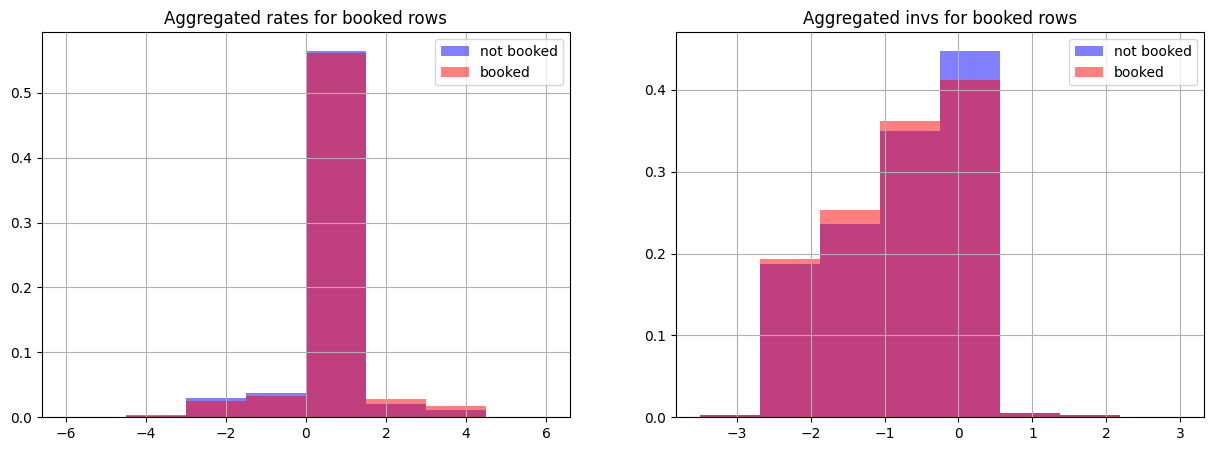

In [22]:
# plot the distribution of the aggregated rates and invs for booked and not booked rows in two separate plots one for rates and one for invs

# normalize the histograms

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].set_title("Aggregated rates for booked rows")

df[df.booking_bool == 0].comp_rate_agg.hist(ax=ax[0], bins=8, color = "blue", density=True, alpha=0.5)

df[df.booking_bool == 1].comp_rate_agg.hist(ax=ax[0], bins=8, color="red", density=True, alpha=0.5)

# create a legend
ax[0].legend(["not booked", "booked"])

# invs

df[df.booking_bool == 0].comp_inv_agg.hist(ax=ax[1], bins=8, color = "blue", density=True, alpha=0.5)
df[df.booking_bool == 1].comp_inv_agg.hist(ax=ax[1], bins=8, color="red", density=True, alpha=0.5)

# create a legend
ax[1].legend(["not booked", "booked"])

ax[1].set_title("Aggregated invs for booked rows")


plt.show()

In [34]:
df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,comp_rate_agg,comp_inv_agg
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,0.0,0.0,NaN,0,NaN,0,0.0,-2.0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,0.0,0.0,NaN,0,NaN,0,0.0,-0.5
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,0.0,0.0,NaN,0,NaN,0,0.0,-2.0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,-1.0,0.0,5.0,0,NaN,0,-3.0,-1.0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,0.0,0.0,NaN,0,NaN,0,0.0,-2.0


In [35]:
prepped_df = df.drop(['comp1_rate','comp1_inv','comp1_rate_percent_diff','comp2_rate','comp2_inv','comp2_rate_percent_diff','comp3_rate','comp3_inv','comp3_rate_percent_diff','comp4_rate','comp4_inv','comp4_rate_percent_diff','comp5_rate','comp5_inv','comp5_rate_percent_diff','comp6_rate','comp6_inv','comp6_rate_percent_diff','comp7_rate','comp7_inv','comp7_rate_percent_diff','comp8_rate','comp8_inv','comp8_rate_percent_diff'],axis=1)

In [36]:
# save the df with the new columns
prepped_df.to_csv("data/aggregated_comp.csv", index=False)


# Anlyzing other missing values

### Setting up

In [39]:
# loading the new df
chunks = pd.read_csv("data/aggregated_comp.csv", chunksize=100000)
comp_df = pd.concat(chunks)

In [58]:
# create a dataframe with number of missing values, count and percentage of missing values for each  column
import math
comp_missing = pd.DataFrame(index = ["missing_values", "count", "n_unique","uniqueness_factor", "percentage_missing"], columns=comp_df.columns)

for c in comp_df.columns:
    comp_missing.loc["missing_values", c] = comp_df[c].isna().sum()
    comp_missing.loc["count", c] = comp_df[c].count()
    comp_missing.loc["n_unique", c] = comp_df[c].nunique()
    comp_missing.loc["uniqueness_factor", c] = -math.log(comp_df[c].nunique() / comp_missing.loc["count", c]) 
    
    
    comp_missing.loc["percentage_missing", c] = (comp_df[c].isna().sum() / comp_df.shape[0] * 100).round(2)

comp_missing.loc["uniqueness_factor"] = comp_missing.loc["uniqueness_factor"].astype(float).round(2)



# save the stats
comp_missing.to_csv("stats/aggregated_comp_stats.csv")



object


### Dealing with the visitor_hist_starrating and visitor_hist_adr_usd columns


In [ ]:
# drop visitor_hist_starrating
filled_df = comp_df.drop(['visitor_hist_starrating'],axis=1)

# count the number of missing values for visitor_hist_adr_usd
hist_usd_missing= filled_df["visitor_hist_adr_usd"].isna().sum()
print(f"the number of missing values for visitor_hist_adr_usd is {hist_usd_missing}")

mean = filled_df["visitor_hist_adr_usd"].mean()

filled_df.groupby("visitor_location_country_id")["visitor_hist_adr_usd"].transform(lambda x: print(len(x), x.mean()))

# fill the missing values of visitor_hist_adr_usd with the mean over visitor_location_country_id
filled_df["visitor_hist_adr_usd"] = filled_df.groupby("visitor_location_country_id")["visitor_hist_adr_usd"].transform(lambda x: x.fillna(x.mean()))

hist_usd_missing= filled_df["visitor_hist_adr_usd"].isna().sum()
print(f"the number of missing values for visitor_hist_adr_usd after first filling by country is {hist_usd_missing}")

# fill the remaining missing values with the mean
filled_df["visitor_hist_adr_usd"] = filled_df["visitor_hist_adr_usd"].fillna(mean)

hist_usd_missing= filled_df["visitor_hist_adr_usd"].isna().sum()
print(f"the number of missing values for visitor_hist_adr_usd after second filling by mean is {hist_usd_missing}")

In [66]:

# get mean and stdv of prop_starrating for rows where prop_review_score is missing
mean = filled_df[filled_df.prop_review_score.isna()]["prop_starrating"].mean()
stdv = filled_df[filled_df.prop_review_score.isna()]["prop_starrating"].std()

print(f"mean: {mean}, stdv: {stdv}")

mean: 2.6564367191743616, stdv: 1.417895793128902


### Dealing with prop_review_score

In [67]:

# fill prop_review_score by prop_id

prop_review_missing = filled_df["prop_review_score"].isna().sum()
print(f"the number of missing values for prop_review_score is {prop_review_missing}")

filled_df["prop_review_score"] = filled_df.groupby("prop_id")["prop_review_score"].transform(lambda x: x.fillna(x.mean()))

prop_review_missing = filled_df["prop_review_score"].isna().sum()
print(f"the number of missing values for prop_review_score after filling by prop_id is {prop_review_missing}")

# fill by prop_starrating
filled_df["prop_review_score"] = filled_df.groupby("prop_starrating")["prop_review_score"].transform(lambda x: x.fillna(x.mean()))

prop_review_missing = filled_df["prop_review_score"].isna().sum()
print(f"the number of missing values for prop_review_score after filling by prop_starrating is {prop_review_missing}")

the number of missing values for prop_review_score is 7364
the number of missing values for prop_review_score after filling by prop_id is 7364
the number of missing values for prop_review_score after filling by prop_starrating is 0


In [68]:
# save the dataset that we have until now
filled_df.to_csv("data/half_filled_dataset.csv", index=False)

## Checkpoint

In [74]:
half_filled_df = pd.read_csv("data/half_filled_dataset.csv")


### Dealing with orig_destination_distance

In [75]:
# get mean of orig_destination_distance
mean = half_filled_df["orig_destination_distance"].mean()


# fill orig_destination_distance by visitor_location_country_id and srch_destination_id
orig_missing = half_filled_df["orig_destination_distance"].isna().sum()
print(f"the number of missing values for orig_destination_distance is {orig_missing}")

half_filled_df["orig_destination_distance"] = half_filled_df.groupby(["visitor_location_country_id", "srch_destination_id"])["orig_destination_distance"].transform(lambda x: x.fillna(x.mean()))

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()
print(f"the number of missing values for orig_destination_distance after filling by visitor_location_country_id and srch_destination_id is {orig_missing}")

# fill the remaining missing values by visitor_location_country_id and prop_country_id

half_filled_df["orig_destination_distance"] = half_filled_df.groupby(["visitor_location_country_id", "prop_country_id"])["orig_destination_distance"].transform(lambda x: x.fillna(x.mean()))

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()

print(f"the number of missing values for orig_destination_distance after filling by visitor_location_country_id and prop_country_id is {orig_missing}")

# fill the remaining missing values by visitor_location_country_id

half_filled_df["orig_destination_distance"] = half_filled_df.groupby(["visitor_location_country_id"])["orig_destination_distance"].transform(lambda x: x.fillna(x.mean()))

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()

print(f"the number of missing values for orig_destination_distance after filling by visitor_location_country_id is {orig_missing}")

# fill the remaining missing values by prop_country_id

half_filled_df["orig_destination_distance"] = half_filled_df.groupby(["prop_country_id"])["orig_destination_distance"].transform(lambda x: x.fillna(x.mean()))

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()

print(f"the number of missing values for orig_destination_distance after filling by prop_country_id is {orig_missing}")

# fill the remaining missing values by prop_id

half_filled_df["orig_destination_distance"] = half_filled_df.groupby(["prop_id"])["orig_destination_distance"].transform(lambda x: x.fillna(x.mean()))

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()

print(f"the number of missing values for orig_destination_distance after filling by prop_id is {orig_missing}")

# fill the remaining by the mean
half_filled_df["orig_destination_distance"] = half_filled_df["orig_destination_distance"].fillna(mean)

orig_missing = half_filled_df["orig_destination_distance"].isna().sum()

print(f"the number of missing values for orig_destination_distance after filling by mean is {orig_missing}")



the number of missing values for orig_destination_distance is 1607782
the number of missing values for orig_destination_distance after filling by visitor_location_country_id and srch_destination_id is 1026687
the number of missing values for orig_destination_distance after filling by visitor_location_country_id and prop_country_id is 757718
the number of missing values for orig_destination_distance after filling by visitor_location_country_id is 716203
the number of missing values for orig_destination_distance after filling by prop_country_id is 42
the number of missing values for orig_destination_distance after filling by prop_id is 42
the number of missing values for orig_destination_distance after filling by mean is 0


In [76]:
# save the dataset that we have until now
half_filled_df.to_csv("data/filled_dataset2.csv", index=False)

### Dealing with srch_query_affinity_score

In [24]:
# fill srch_query_affinity_score by the min
half_filled_df = pd.read_csv("data/filled_dataset2.csv")

# calculate percentage of missing values
missing = half_filled_df["srch_query_affinity_score"].isna().sum()
percentage = missing / half_filled_df.shape[0] * 100

print(f"the number of missing values for srch_query_affinity_score is {missing}")
print(f"the percentage of missing values for srch_query_affinity_score is {percentage}")

the number of missing values for srch_query_affinity_score is 4640941
the percentage of missing values for srch_query_affinity_score is 93.5985520981085


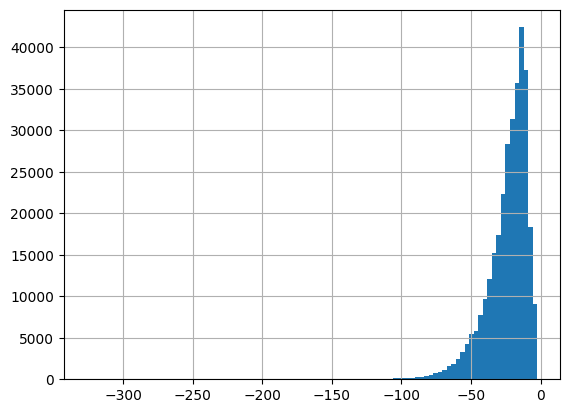

In [33]:


# blot the distribution of srch_query_affinity_score
half_filled_df["srch_query_affinity_score"].hist(bins=100)

plt.show()

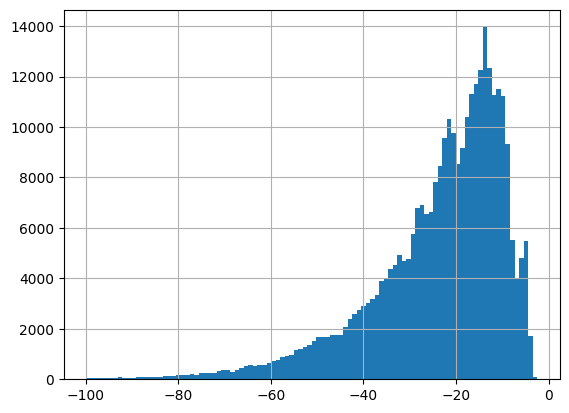

In [25]:
# remove outliers on the lower side
half_filled_df["srch_query_affinity_score"] = half_filled_df["srch_query_affinity_score"].apply(lambda x: x if x > -100 else None)

# blot the distribution of srch_query_affinity_score
half_filled_df["srch_query_affinity_score"].hist(bins=100)

plt.show()

In [26]:
from scipy.stats import gamma



# number of missing values
total_missing = half_filled_df["srch_query_affinity_score"].isna().sum()

print(f"the number of missing values for srch_query_affinity_score is {total_missing}")
positive_data = -half_filled_df[['srch_query_affinity_score']].dropna()

print("data converted to positive values")

# Step 2: Fit a gamma distribution to the positive data
alpha, loc, beta = gamma.fit(positive_data)  # We fix the location to 0 for simplicity



print(f"alpha: {alpha}, loc: {loc}, beta: {beta}")

the number of missing values for srch_query_affinity_score is 4641850
data converted to positive values
alpha: 2.2923735174410775, loc: 2.492503138917892, beta: 9.320931628200325


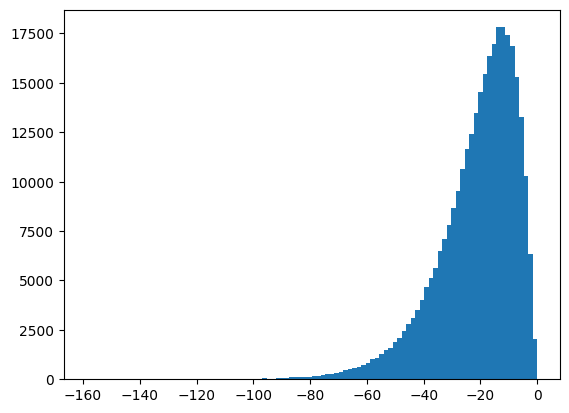

In [28]:
# histogram of sample data from the distrinution the size should be the same as the number of non missing values
sample = gamma.rvs(alpha, loc=loc, scale=beta, size=positive_data.shape[0])

plt.hist(-sample, bins=100)
plt.show()

target mean: 72.60821599999998


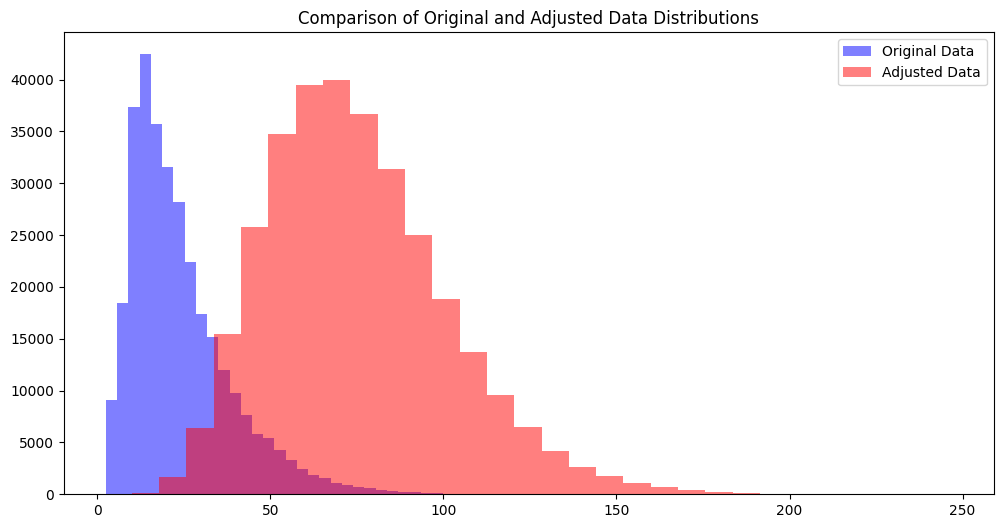

In [37]:
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt

# Assume these are your original parameters
original_alpha = alpha
original_beta = beta

# Compute new mean (e.g., targeting the first percentile as new mean)
target_mean = np.percentile(positive_data, 99)  # Assuming positive_data exists

print(f"target mean: {target_mean}")
new_alpha = target_mean / beta

# Generate new adjusted data with the same variance but different mean
adjusted_data = gamma.rvs(new_alpha, scale=beta,loc=loc, size=positive_data.shape[0])

# Visual comparison
plt.figure(figsize=(12, 6))
plt.hist(positive_data, bins=30, alpha=0.5, label='Original Data', color='blue')
plt.hist(adjusted_data, bins=30, alpha=0.5, label='Adjusted Data', color='red')
plt.legend()
plt.title('Comparison of Original and Adjusted Data Distributions')
plt.show()


In [42]:
# Step 3: Sample new data points using the fitted parameters
sampled_data = gamma.rvs(new_alpha, scale=beta, loc = loc, size=total_missing)

# convert to negative and to a pandas series
sampled_data = -pd.Series(sampled_data)

print(f"the number of sampled values is {sampled_data.shape[0]}")
print(f"the number of missing values is {half_filled_df["srch_query_affinity_score"].isna().sum()}")
print(f"the number of missing values in the sampled data is {sampled_data.isna().sum()}")

missing_indices = half_filled_df["srch_query_affinity_score"].isna()
half_filled_df.loc[missing_indices, "srch_query_affinity_score"] = sampled_data.values


the number of sampled values is 4641850
the number of missing values is 4641850
the number of missing values in the sampled data is 0


<Axes: >

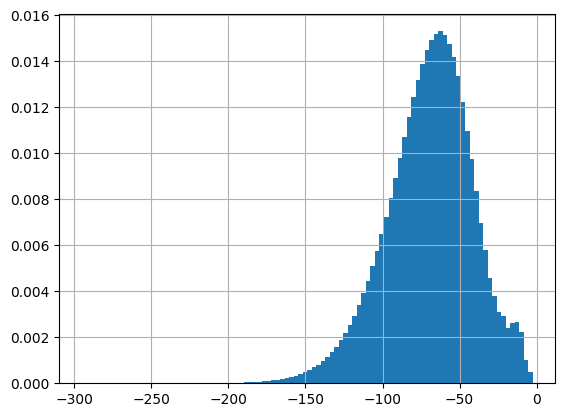

In [44]:
# plot the distribution of the filled srch_query_affinity_score
half_filled_df["srch_query_affinity_score"].hist(bins=100, density=True)    


In [45]:
# save the dataset that we have until now
half_filled_df.to_csv("data/filled_dataset3.csv", index=False)

### Dealing with prop_location_score2

In [109]:
# check if location_score1 and location_score2 are correlated
half_filled_df = pd.read_csv("data/filled_dataset3.csv")

# calculate the correlation
correlation = half_filled_df["prop_location_score1"].corr(half_filled_df["prop_location_score2"])

print(f"the correlation between prop_location_score1 and prop_location_score2 is {correlation}")

the correlation between prop_location_score1 and prop_location_score2 is 0.43598316725629005


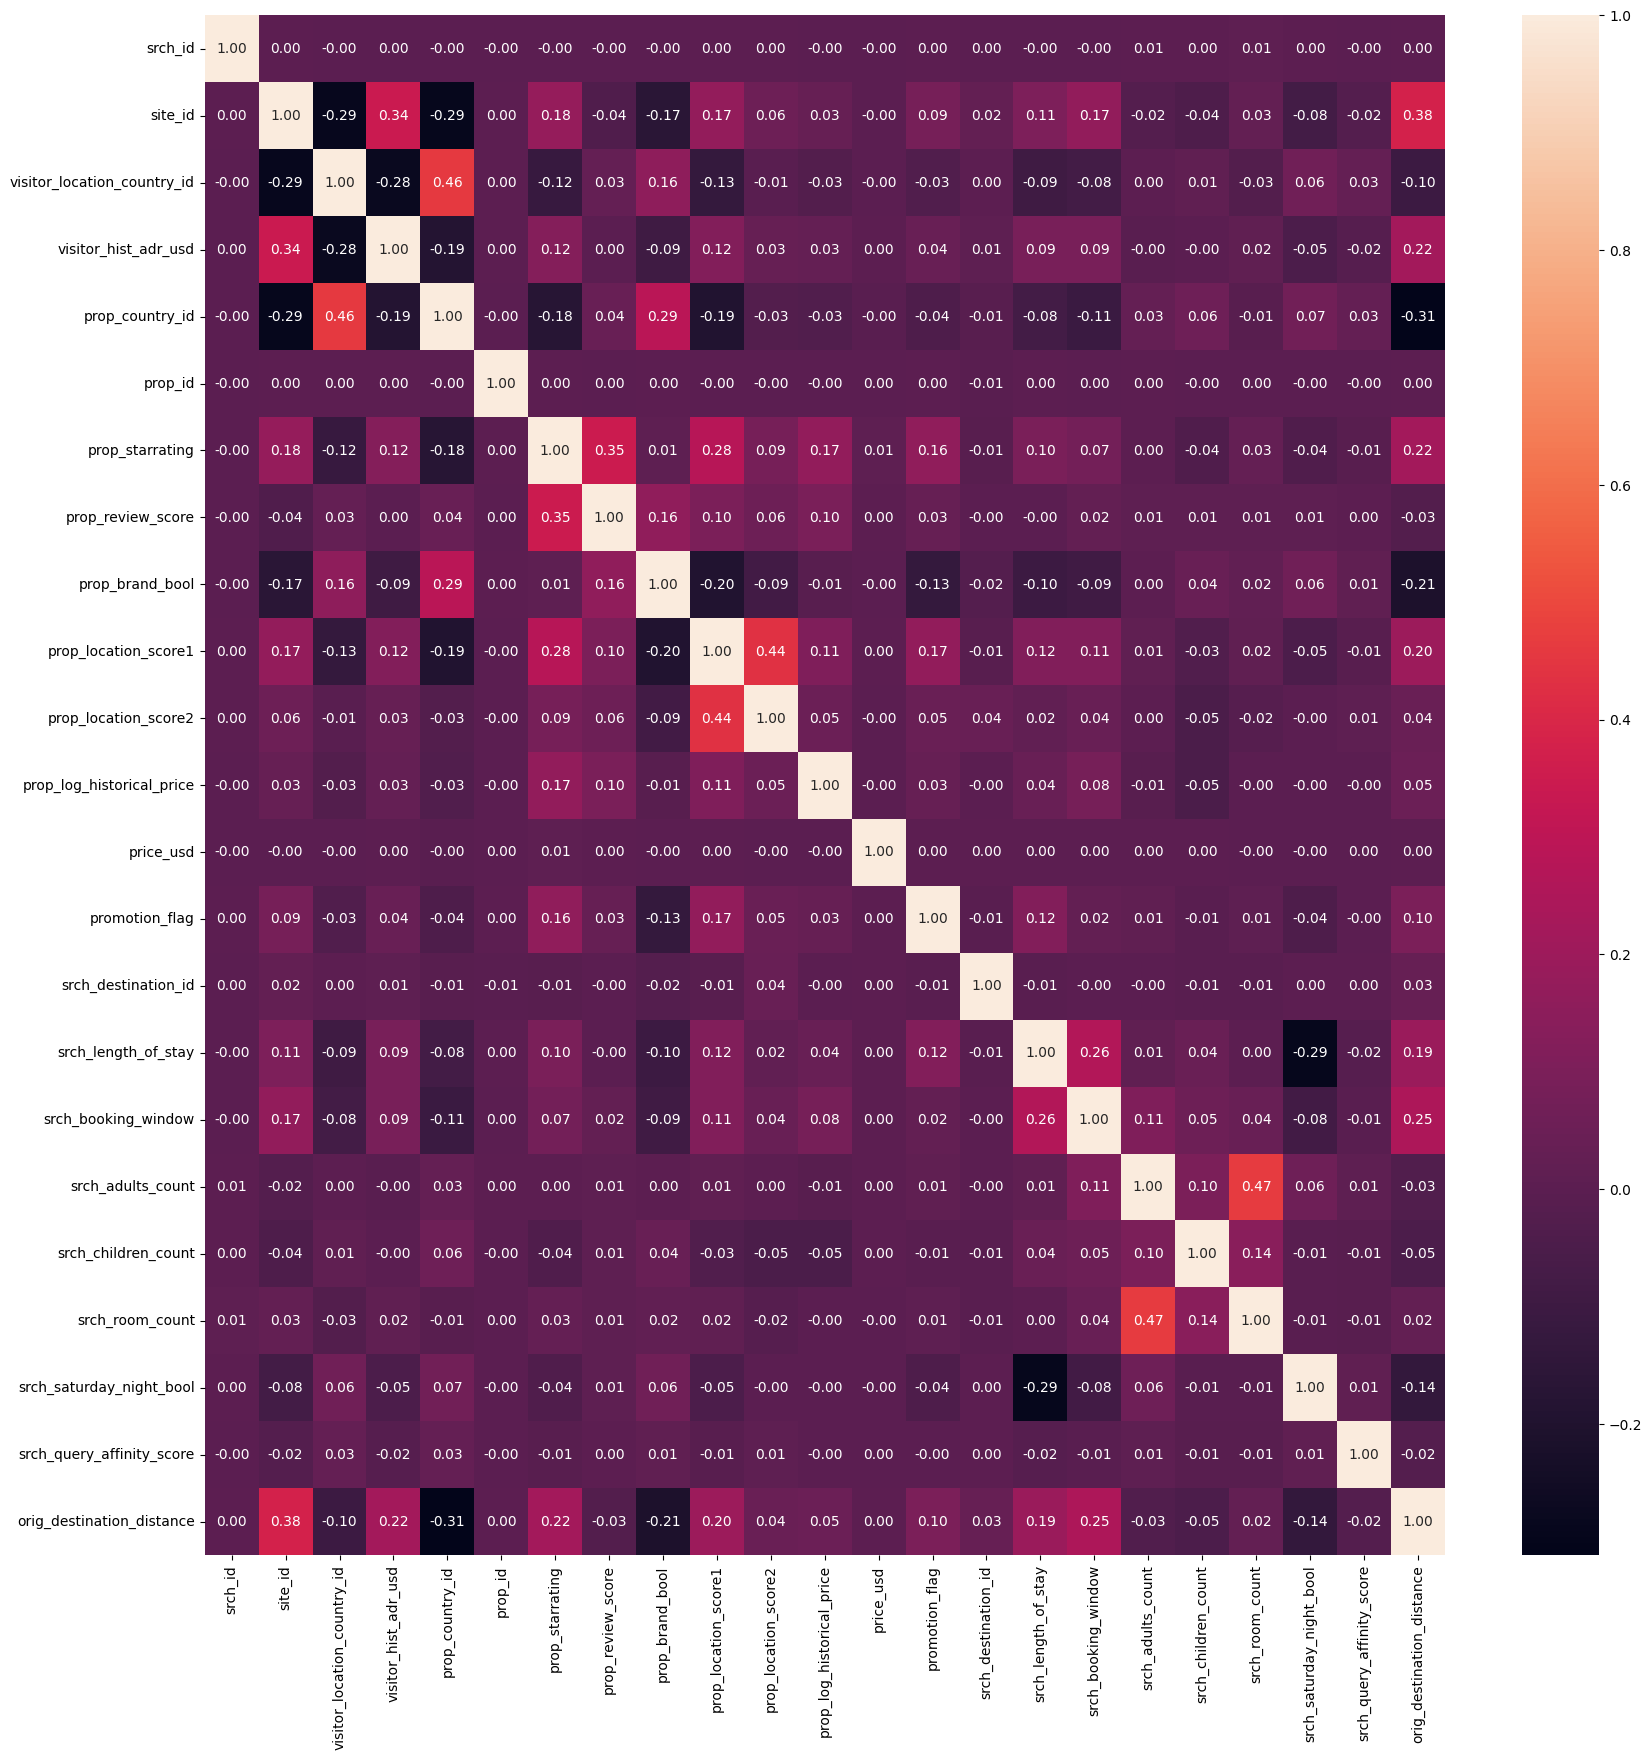

In [110]:
# check if location_score2 can be predicted by location_score1 and other features

# drop the rows with missing values
loc_score_df = half_filled_df.dropna(subset=["prop_location_score2", "prop_location_score1"])

loc_score_df = loc_score_df.drop(['date_time', 'position', 'click_bool', 'gross_bookings_usd', 'booking_bool', 'random_bool', 'comp_rate_agg', 'comp_inv_agg'], axis=1)

# plot the correlation matrix of all features
import seaborn as sns

correlation_matrix = loc_score_df.corr()

plt.figure(figsize=(20, 20))

# format the correlation matrix with 2 decimal points
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")

plt.show()





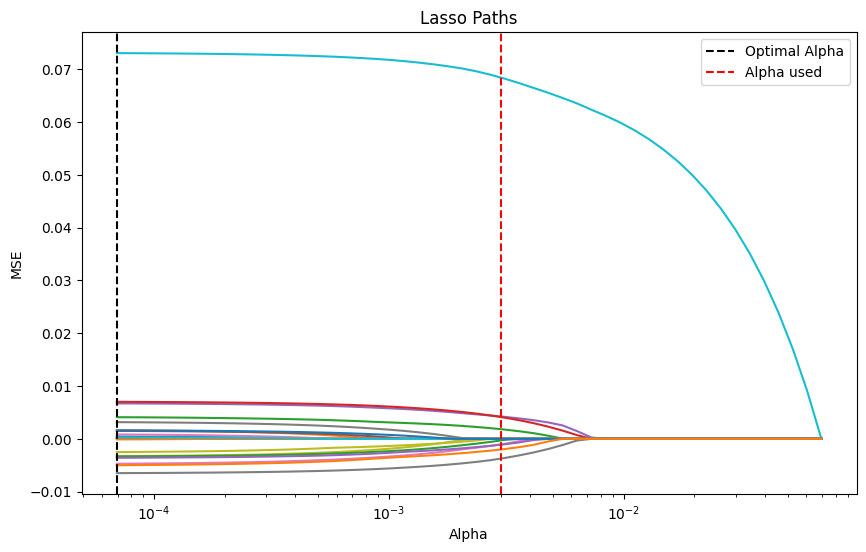

Text(0.5, 1.0, 'MSE for each Alpha')

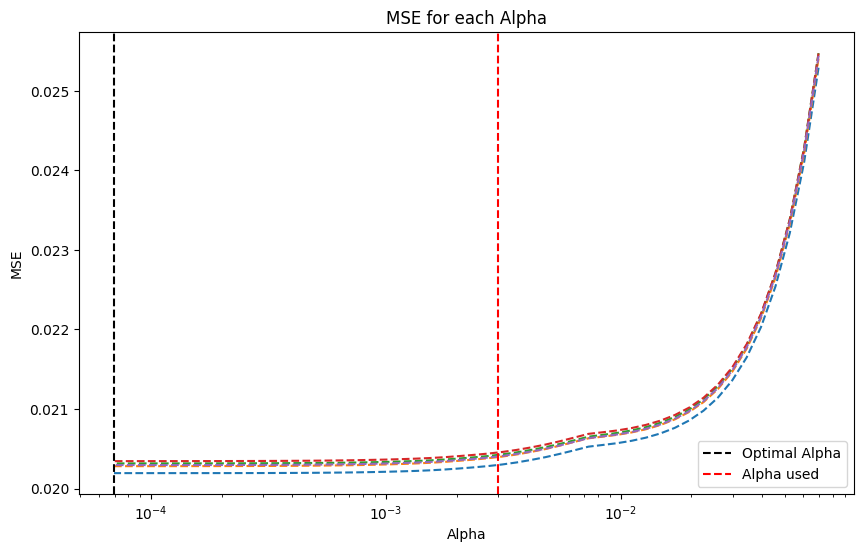

In [111]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Select features and target variable
X = loc_score_df.drop(["prop_location_score2"], axis=1)
y = loc_score_df["prop_location_score2"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize LassoCV
model = LassoCV(cv=5, random_state=42, n_alphas=50, n_jobs=4)

# Fit the LassoCV model
model.fit(X_train_scaled, y_train)

# Plot the coefficient path # set log scale for x-axis
plt.figure(figsize=(10, 6))
plt.semilogx()

# Display each feature's coefficient path

coefs = []
for a in model.alphas_:
    model_for_alpha = Lasso(alpha=a)
    model_for_alpha.fit(X_train_scaled, y_train)
    coefs.append(model_for_alpha.coef_)



plt.plot(model.alphas_, coefs)

# Highlight the optimal alpha
plt.axvline(x=model.alpha_, color='black', linestyle='--', label='Optimal Alpha')

alpha_used = 10**-3 * 3
plt.axvline(x=alpha_used, color='red', linestyle='--', label='Alpha used')

plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Lasso Paths')
plt.legend()
plt.axis('tight')
plt.semilogx()  # Change x-axis to log-scale for better visualization
plt.show()

# plot the mse for each alpha
plt.figure(figsize=(10, 6))
plt.semilogx() 
plt.plot(model.alphas_, model.mse_path_, linestyle='--')
plt.axvline(model.alpha_, linestyle='--', color='k', label='Optimal Alpha')
plt.axvline(alpha_used, color='red', linestyle='--', label='Alpha used')
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE for each Alpha')



Test MSE: 0.02048208301509305
Selected features: Index(['visitor_location_country_id', 'prop_country_id', 'prop_starrating',
       'prop_location_score1', 'promotion_flag', 'srch_destination_id',
       'srch_length_of_stay', 'srch_children_count',
       'orig_destination_distance'],
      dtype='object')
Final Test MSE: 0.020406255000605323


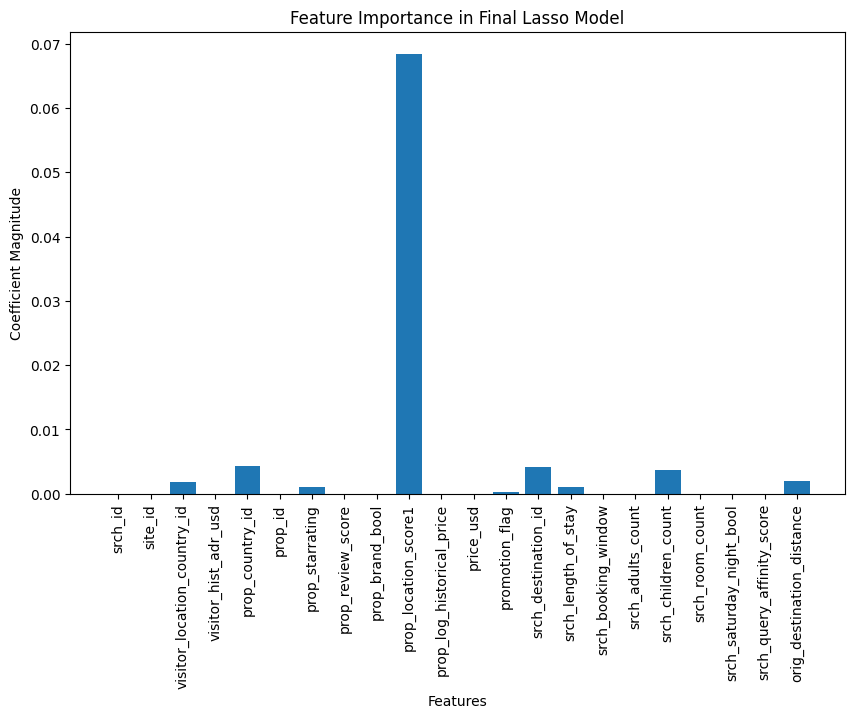

In [112]:
# Evaluate the model on the test set
from sklearn.linear_model import LinearRegression

final_model = Lasso(alpha=alpha_used)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse}")

# Identify non-zero features and retrain model
selected_features = X.columns[final_model.coef_ != 0]
print("Selected features:", selected_features)

# Retrain Lasso model using only selected features
X_train_selected = X_train_scaled[:, final_model.coef_ != 0]
X_test_selected = X_test_scaled[:, final_model.coef_ != 0]


# fit a linear regression model

# Initialize the model
linear_model = LinearRegression()

# Fit the model on the selected features
linear_model.fit(X_train_selected, y_train)


# Evaluate the final model on the test set
final_y_pred = linear_model.predict(X_test_selected)
final_test_mse = mean_squared_error(y_test, final_y_pred)
print(f"Final Test MSE: {final_test_mse}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.bar( X.columns, np.abs(final_model.coef_))
plt.xlabel("Features")
plt.xticks(rotation=90)
plt.ylabel("Coefficient Magnitude")
plt.title("Feature Importance in Final Lasso Model")
plt.show()

(array([1.0000e+00, 1.2000e+01, 1.1300e+02, 5.4800e+02, 1.2930e+03,
        2.2730e+03, 3.5040e+03, 4.9060e+03, 6.3620e+03, 9.1800e+03,
        1.2298e+04, 1.5933e+04, 2.1159e+04, 2.7665e+04, 3.3653e+04,
        4.0749e+04, 4.6672e+04, 4.9455e+04, 4.9020e+04, 4.7413e+04,
        4.4242e+04, 3.9264e+04, 3.5508e+04, 3.2540e+04, 2.7781e+04,
        2.3917e+04, 2.0767e+04, 1.6619e+04, 1.5025e+04, 1.2337e+04,
        1.0463e+04, 9.8800e+03, 8.5540e+03, 7.6060e+03, 6.7590e+03,
        6.5870e+03, 6.0700e+03, 5.7670e+03, 5.3540e+03, 4.8440e+03,
        4.3390e+03, 4.2970e+03, 3.9380e+03, 3.7430e+03, 3.6200e+03,
        3.6620e+03, 3.4060e+03, 2.7550e+03, 2.5140e+03, 2.1260e+03,
        2.0670e+03, 2.1020e+03, 2.1780e+03, 1.9160e+03, 1.6170e+03,
        1.4450e+03, 1.2990e+03, 1.2350e+03, 1.2120e+03, 1.1700e+03,
        9.8900e+02, 1.0150e+03, 9.2100e+02, 7.8400e+02, 6.8000e+02,
        6.1600e+02, 6.7300e+02, 6.8800e+02, 5.7500e+02, 5.4300e+02,
        5.1800e+02, 4.2500e+02, 2.9500e+02, 2.68

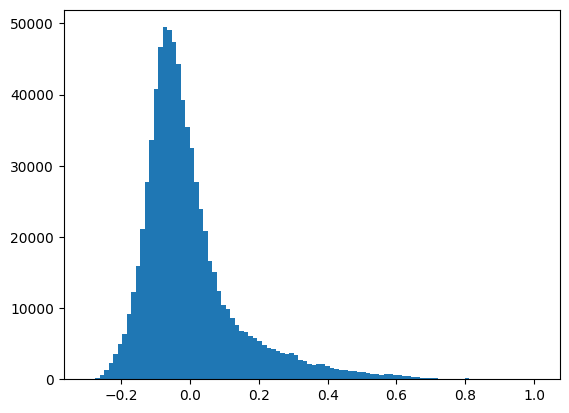

In [113]:
# check the normality of the residuals
residuals = y_test - final_y_pred

plt.hist(residuals, bins=100)

<Axes: >

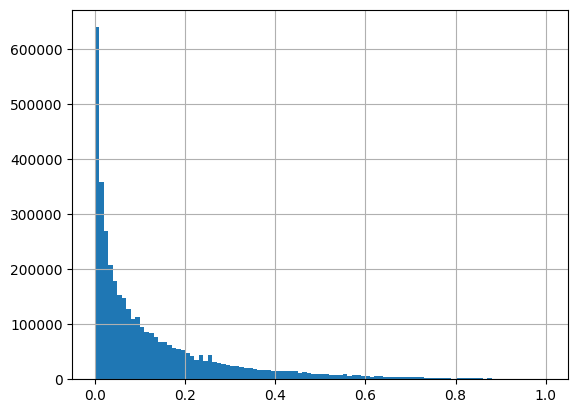

In [114]:
# plot distribution of prop_location_score2
loc_score_df["prop_location_score2"].hist(bins=100)

In [115]:
from sklearn.linear_model import LinearRegression


# fit the model on the whole dataset and use it to predict the missing values
# Select features and target variable
X = loc_score_df.drop(["prop_location_score2"], axis=1)
X_selected = X[selected_features]

y = loc_score_df["prop_location_score2"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# train the linear model above on the whole dataset
reg = LinearRegression().fit(X_scaled, y)


# Select rows with missing values
missing_indices = half_filled_df["prop_location_score2"].isna()
X_missing = half_filled_df.loc[missing_indices, selected_features]

# Standardize the missing data
X_missing_scaled = scaler.transform(X_missing)

# Predict the missing values
y_missing = reg.predict(X_missing_scaled)

# Fill the missing values in the original DataFrame
half_filled_df.loc[missing_indices, "prop_location_score2"] = y_missing




<Axes: >

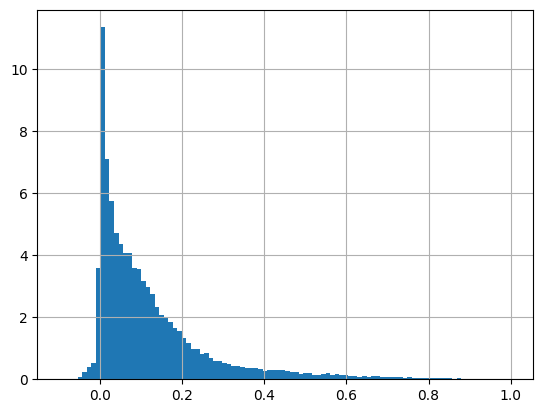

In [116]:
# plot the distribution of the filled prop_location_score2
half_filled_df["prop_location_score2"].hist(bins=100, density=True)

In [117]:
# print the number of missing values
missing = half_filled_df["prop_location_score2"].isna().sum()
print(f"the number of missing values for prop_location_score2 is {missing}")

the number of missing values for prop_location_score2 is 0


In [118]:
# drop gross_bookings_usd
filled_df = half_filled_df.drop(['gross_bookings_usd'],axis=1)

In [119]:
# save the completed dataset
filled_df.to_csv("data/filled_dataset.csv", index=False)

# Test data

### Setup

In [1]:
import pandas as pd
import dataset_utils as du

In [2]:
# remove filling_values module from memory if present
if 'fv' in globals():
    #del fv
    # delete it from the ipython environment
    %xdel fv

import filling_values as fv


In [3]:
original_test_df = pd.read_csv("data/test_set_VU_DM.csv")

In [4]:
stats = du.missingness_and_uniqueness(original_test_df)
stats.to_csv("stats/test_missingness_stats.csv")

In [5]:
original_train_df = pd.read_csv("data/training_set_VU_DM.csv")

In [6]:
# deep copy the original dataframe
train_df = original_train_df.copy(deep=True)
test_df = original_test_df.copy(deep=True)

## Testing filling functions

In [ ]:
train_df = train_df.drop(["gross_bookings_usd"], axis=1)

In [6]:
train_df = fv.aggregate_comp(train_df)

In [7]:
visitor_hist_filler = fv.VisitorHistFiller()
train_df = visitor_hist_filler.fit_transform(train_df)



the number of missing values for visitor_hist_adr_usd is 4705359
the number of missing values for visitor_hist_adr_usd after first filling by country is 16922
the number of missing values for visitor_hist_adr_usd after second filling by mean is 0


In [8]:
test_df = fv.aggregate_comp(test_df)
test_df = visitor_hist_filler.transform(test_df)



the number of missing values for visitor_hist_adr_usd is 4704559
the number of missing values for visitor_hist_adr_usd after first filling by country is 16981
the number of missing values for visitor_hist_adr_usd after second filling by mean is 0


In [9]:
prop_review_filler = fv.PropReviewScoreFiller()

In [10]:
train_df = prop_review_filler.fit_transform(train_df)

The number of missing values for prop_review_score is 7364
The number of missing values for prop_review_score after filling by prop_starrating is 0
The number of missing values for prop_review_score after filling by global mean is 0


In [11]:

test_df = prop_review_filler.transform(test_df)

The number of missing values for prop_review_score is 7266
The number of missing values for prop_review_score after filling by prop_starrating is 0
The number of missing values for prop_review_score after filling is 0


In [12]:
dest_dist_filler = fv.DestinationDistanceFiller()

train_df = dest_dist_filler.fit_transform(train_df)

The number of missing values for orig_destination_distance is 1607782
The number of missing values after filling by visitor_location_country_id and srch_destination_id is 1026687
The number of missing values after filling by visitor_location_country_id and prop_country_id is 757718
The number of missing values after filling by visitor_location_country_id is 716203
The number of missing values after filling by prop_country_id is 42
The number of missing values after filling by prop_id is 42
The number of missing values after filling by mean is 0


In [13]:
test_df = dest_dist_filler.transform(test_df)

The number of missing values for orig_destination_distance is 1608679
The number of missing values after filling by visitor_location_country_id and srch_destination_id is 1029713
The number of missing values after filling by visitor_location_country_id and prop_country_id is 760011
The number of missing values after filling by visitor_location_country_id is 720299
The number of missing values after filling by prop_country_id is 24
The number of missing values after filling by prop_id is 24
The number of missing values for orig_destination_distance after filling is 0


In [14]:
query_affinity_filler = fv.QueryAffinityFiller()

train_df = query_affinity_filler.fit_transform(train_df)



the number of missing values for srch_query_affinity_score is 4640941
data converted to positive values
alpha: 2.2321718057601956, loc: 2.493473251971322, beta: 9.611667478549268
target mean: 76.24383500000002
the number of sampled values is 4640941
the number of missing values is 4640941
the number of missing values in the sampled data is 0


In [15]:

test_df = query_affinity_filler.transform(test_df)



the number of missing values for srch_query_affinity_score is 4641025
the number of missing values in the sampled data is 0


In [16]:
loc_score_filler = fv.LocationScoreFiller()

train_df = loc_score_filler.fit_transform(train_df)

In [17]:
test_df = loc_score_filler.transform(test_df)

### Using the all encluding class


In [7]:
filler = fv.MissingValuesFiller()

In [8]:
train_df = filler.fit_transform(train_df)

Starting fit_transform process...
dropped gross_bookings_usd column
Aggregating comp columns..

Filling visitor history ADR USD...
dropped visitor_hist_starrating column
the number of missing values for visitor_hist_adr_usd is 4705359
the number of missing values for visitor_hist_adr_usd after first filling by country is 16922
the number of missing values for visitor_hist_adr_usd after second filling by mean is 0

Filling property review scores...
The number of missing values for prop_review_score is 7364
The number of missing values for prop_review_score after filling by prop_starrating is 0
The number of missing values for prop_review_score after filling by global mean is 0

Filling original destination distances...
The number of missing values for orig_destination_distance is 1607782
The number of missing values after filling by visitor_location_country_id and srch_destination_id is 1026687
The number of missing values after filling by visitor_location_country_id and prop_country_id

In [9]:
test_df = filler.transform(test_df)

Starting transform process...
Aggregating comp columns..

Filling visitor history ADR USD...
dropped visitor_hist_starrating column
the number of missing values for visitor_hist_adr_usd is 4704559
the number of missing values for visitor_hist_adr_usd after first filling by country is 16981
the number of missing values for visitor_hist_adr_usd after second filling by mean is 0

Filling property review scores...
The number of missing values for prop_review_score is 7266
The number of missing values for prop_review_score after filling by prop_starrating is 0
The number of missing values for prop_review_score after filling is 0

Filling original destination distances...
The number of missing values for orig_destination_distance is 1608679
The number of missing values after filling by visitor_location_country_id and srch_destination_id is 1029713
The number of missing values after filling by visitor_location_country_id and prop_country_id is 760011
The number of missing values after filling

In [10]:
train_df.columns

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating',
       'prop_review_score', 'prop_brand_bool', 'prop_location_score1',
       'prop_location_score2', 'prop_log_historical_price', 'position',
       'price_usd', 'promotion_flag', 'srch_destination_id',
       'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count',
       'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool',
       'srch_query_affinity_score', 'orig_destination_distance', 'random_bool',
       'click_bool', 'booking_bool', 'comp_rate_agg', 'comp_inv_agg'],
      dtype='object')

In [11]:
# save the filled datasets
train_df.to_csv("data/filled_train.csv", index=False)
test_df.to_csv("data/filled_test.csv", index=False)

In [12]:
stats_train = du.missingness_and_uniqueness(train_df)
stats_test = du.missingness_and_uniqueness(test_df)

stats_train.to_csv("stats/filled_train_missingness_stats.csv")
stats_test.to_csv("stats/filled_test_missingness_stats.csv")

### Similarity

In [ ]:
# Things to plot to visualize the data:
# - comparison of distribution of each column, for booked and not booked rows
# - comparison of distribution of each column, for clicked and not clicked rows
# - distribution of sum rowwise, for clicked and not clicked rows
# - max rowwise, for clicked and not clicked rows
# - min rowwise, for clicked and not clicked rows
# - kurtosis rowwise, for clicked and not clicked rows
# - skewness rowwise, for clicked and not clicked rows
# - correlation matrix for all columns

# Outdated code

In [ ]:
import numpy as np
from tqdm import tqdm

rate_columns = [c for c in df.columns if "rate" in c]
# iterate over the rows
cases_counts = np.zeros(5)
for i, row in tqdm(df.iterrows(), desc="rows"):

    #case 5
    if row[rate_columns].isna().all():
        df.loc[i, "comp_rate_agg"] = 0

        cases_counts[4] += 1

        continue
    
    # case 1
    
    case1 = all([row[c] == 0 or pd.isna(row[c]) for c in rate_columns])
    if case1:
        df.loc[i, "comp_rate_agg"] = 0

        cases_counts[0] += 1
        continue

    # case 2
    case2 = all([row[c] == 1 or pd.isna(row[c]) for c in rate_columns])
    if case2:

        df.loc[i, "comp_rate_agg"] = 1

        cases_counts[1] += 1
        continue

    # case 3

    case3 = all([row[c] == -1 or pd.isna(row[c]) for c in rate_columns])
    if case3:
        df.loc[i, "comp_rate_agg"] = -1

        cases_counts[2] += 1
        continue

    # case 4
    df.loc[i, "comp_rate_agg"] = row[rate_columns].mean()

    cases_counts[3] += 1

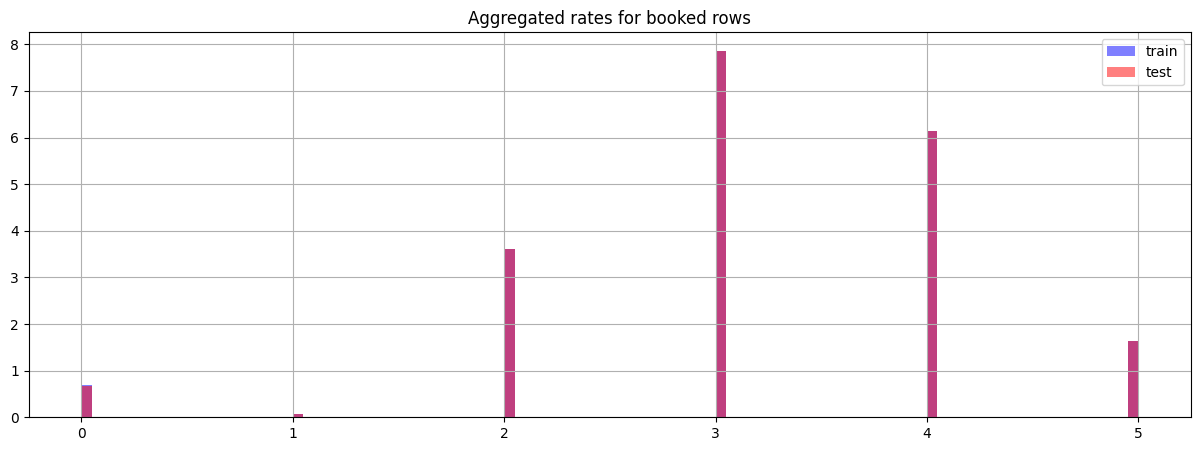

In [15]:
# plot distribution of prop_review_score for train and test on the same plot with alpha=0.5

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

ax.set_title("Aggregated rates for booked rows")

train_df["prop_starrating"].hist(ax=ax, bins=100, color = "blue", density=True, alpha=0.5)

test_df["prop_starrating"].hist(ax=ax, bins=100, color="red", density=True, alpha=0.5)

# create a legend
ax.legend(["train", "test"])

plt.show()

